In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, RandomSampler, TensorDataset, Dataset, random_split
import torch
from transformers import get_scheduler
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support, fbeta_score
import json
import pandas as pd
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline
from transformers import DistilBertTokenizerFast, DistilBertForTokenClassification
from torch.nn.utils.rnn import pad_sequence
from torch.optim import AdamW
import warnings
warnings.filterwarnings('ignore')
# Setting the seed for reproducibility
torch.manual_seed(42)

# Checking if CUDA is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Loading the JSON data
with open('/kaggle/input/pii-detection-removal-from-educational-data/train.json', 'r') as file:
    data = json.load(file)

# Converting to DataFrame
data = pd.json_normalize(data)
data.head()

In [ ]:
data.isnull().sum()

,0
document,0
full_text,0
tokens,0
trailing_whitespace,0
labels,0


In [ ]:
# Label counts and frequency
label_counts = data['labels'].explode().value_counts()
print(label_counts)

labels
O                   4989794
B-NAME_STUDENT         1365
I-NAME_STUDENT         1096
B-URL_PERSONAL          110
B-ID_NUM                 78
B-EMAIL                  39
I-STREET_ADDRESS         20
I-PHONE_NUM              15
B-USERNAME                6
B-PHONE_NUM               6
B-STREET_ADDRESS          2
I-URL_PERSONAL            1
I-ID_NUM                  1
Name: count, dtype: int64


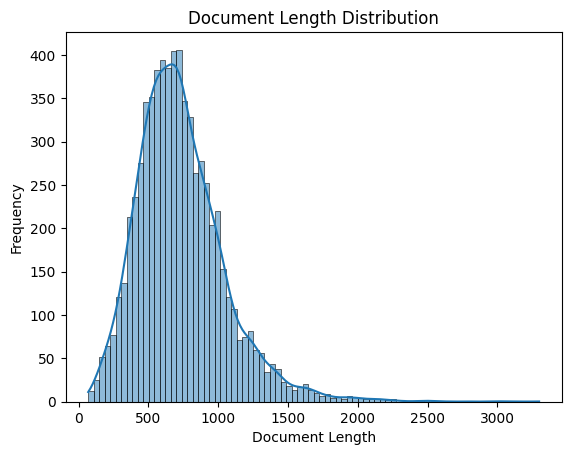

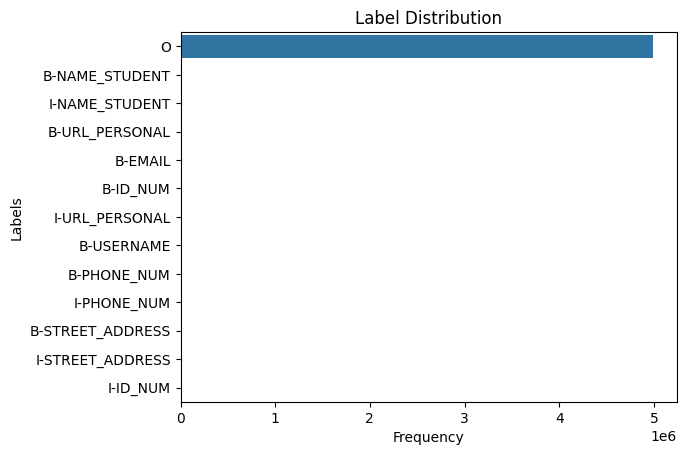

In [ ]:
# Visualizing the distribution of document lengths
doc_lengths = data['tokens'].apply(len)
sns.histplot(doc_lengths, kde=True)
plt.title('Document Length Distribution')
plt.xlabel('Document Length')
plt.ylabel('Frequency')
plt.show()

# Visualizing label distributions
sns.countplot(y=data['labels'].explode())
plt.title('Label Distribution')
plt.xlabel('Frequency')
plt.ylabel('Labels')
plt.show()

In [ ]:
# Looking for unusually long or short documents
print("Longest document length:", doc_lengths.max())
print("Shortest document length:", doc_lengths.min())

# Checking for unusual labels
unusual_labels = label_counts[label_counts < 10]  #Arbitrary threshold
print("Unusual Labels:", unusual_labels)

Longest document length: 3298
Shortest document length: 69
Unusual Labels: labels
B-USERNAME          6
B-PHONE_NUM         6
B-STREET_ADDRESS    2
I-URL_PERSONAL      1
I-ID_NUM            1
Name: count, dtype: int64


In [ ]:
def load_data(filename):
    return pd.read_json(filename)

# Load data
test_data = load_data('/content/test.json')
train_data = load_data('/content/train.json')

In [ ]:
test_data

,document,full_text,tokens,trailing_whitespace
0,7,Design Thinking for innovation reflexion-Avril...,"[Design, Thinking, for, innovation, reflexion,...","[True, True, True, True, False, False, True, F..."
1,10,Diego Estrada\n\nDesign Thinking Assignment\n\...,"[Diego, Estrada, \n\n, Design, Thinking, Assig...","[True, False, False, True, True, False, False,..."
2,16,Reporting process\n\nby Gilberto Gamboa\n\nCha...,"[Reporting, process, \n\n, by, Gilberto, Gambo...","[True, False, False, True, True, False, False,..."
3,20,Design Thinking for Innovation\n\nSindy Samaca...,"[Design, Thinking, for, Innovation, \n\n, Sind...","[True, True, True, False, False, True, False, ..."
4,56,Assignment: Visualization Reflection Submitt...,"[Assignment, :, , Visualization, , Reflecti...","[False, False, False, False, False, False, Fal..."
5,86,Cheese Startup - Learning Launch ​by Eladio Am...,"[Cheese, Startup, -, Learning, Launch, ​by, El...","[True, True, True, True, True, True, True, Fal..."
6,93,Silvia Villalobos\n\nChallenge:\n\nThere is a ...,"[Silvia, Villalobos, \n\n, Challenge, :, \n\n,...","[True, False, False, False, False, False, True..."
7,104,Storytelling The Path to Innovation\n\nDr Sak...,"[Storytelling, , The, Path, to, Innovation, \...","[True, False, True, True, True, False, False, ..."
8,112,Reflection – Learning Launch\n\nFrancisco Ferr...,"[Reflection, –, Learning, Launch, \n\n, Franci...","[True, True, True, False, False, True, False, ..."
9,123,Gandhi Institute of Technology and Management ...,"[Gandhi, Institute, of, Technology, and, Manag...","[True, True, True, True, True, True, False, Tr..."


In [ ]:
label_map = {label: i for i, label in enumerate(['O', 'B-NAME_STUDENT', 'I-NAME_STUDENT', 'B-URL_PERSONAL', 'I-URL_PERSONAL', 'B-EMAIL', 'I-EMAIL', 'B-PHONE_NUM', 'I-PHONE_NUM', 'B-ID_NUM', 'I-ID_NUM', 'B-USERNAME', 'I-USERNAME', 'B-STREET_ADDRESS', 'I-STREET_ADDRESS'])}

### Initializing the tokenizer and model

In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_checkpoint)
model = DistilBertForTokenClassification.from_pretrained(model_checkpoint, num_labels=NUM_LABELS)
model.to(device)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForTokenClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task

DebertaV2ForTokenClassification(
  (deberta): DebertaV2Model(
    (embeddings): DebertaV2Embeddings(
      (word_embeddings): Embedding(128100, 768, padding_idx=0)
      (LayerNorm): LayerNorm((768,), eps=1e-07, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): DebertaV2Encoder(
      (layer): ModuleList(
        (0-11): 12 x DebertaV2Layer(
          (attention): DebertaV2Attention(
            (self): DisentangledSelfAttention(
              (query_proj): Linear(in_features=768, out_features=768, bias=True)
              (key_proj): Linear(in_features=768, out_features=768, bias=True)
              (value_proj): Linear(in_features=768, out_features=768, bias=True)
              (pos_dropout): Dropout(p=0.1, inplace=False)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): DebertaV2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNor

### Preprocessing

In [ ]:
def tokenize_and_align_labels(data, tokenizer, label_map):
    tokenized_inputs = tokenizer(data['tokens'].tolist(), truncation=True, padding='max_length', is_split_into_words=True, return_tensors="pt", max_length=512)
    labels = []
    for i, label_list in enumerate(data['labels']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)  # Maping tokens to their word IDs
        label_ids = []
        previous_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)  # Special tokens receive a label of -100
            elif word_id != previous_word_id:
                label_ids.append(label_map[label_list[word_id]])  # Only label the first token of a given word
            else:
                label_ids.append(-100)  # Subsequent tokens receive a label of -100
            previous_word_id = word_id

        labels.append(torch.tensor(label_ids))

    tokenized_inputs['labels'] = pad_sequence(labels, batch_first=True, padding_value=-100)
    return tokenized_inputs

In [ ]:
# proceeding with tokenization and aligning labels
train_tokenized = tokenize_and_align_labels(train_data, tokenizer, label_map)

### Splitting the train dataset into train and val sets.

In [ ]:
class PIIDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings.input_ids)

dataset = PIIDataset(train_tokenized)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

### Defining data loaders

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

### Defining optimizer and metrics

In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

#Collecting metrics and losses for plotting
train_losses, val_losses = [], []
accuracies, f1_scores, fbeta_scores = [], [], []

### Training the model

In [ ]:
def train_epoch(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    for batch in data_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    return total_loss / len(data_loader)

### Evaluting the model

In [ ]:
def eval_model(model, data_loader, device):
    model.eval()
    total_loss = 0
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            total_loss += loss.item()

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = batch['labels'].detach().cpu().numpy()

            # Converting logits to predicted labels
            pred_flat = np.argmax(logits, axis=2).flatten()
            labels_flat = label_ids.flatten()
            predictions.extend(pred_flat[labels_flat != -100])
            true_labels.extend(labels_flat[labels_flat != -100])

    accuracy = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='weighted')
    fbeta = fbeta_score(true_labels, predictions, beta=5, average='micro')

    return total_loss / len(data_loader), accuracy, f1, fbeta

### Training and Evalution loop

In [ ]:
for epoch in range(10):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss, accuracy, f1, fbeta = eval_model(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    accuracies.append(accuracy)
    f1_scores.append(f1)
    fbeta_scores.append(fbeta)

    print(f"Epoch {epoch + 1}, Train Loss: {train_loss}, Val Loss: {val_loss}, Accuracy: {accuracy}, F1: {f1}, FBeta: {fbeta}")

Epoch 1, Train Loss: 0.015197917206626867, Val Loss: 0.0017245822972127873, Accuracy: 0.9997547012930746, F1: 0.9996951523385583, FBeta: 0.9997547012930746
Epoch 2, Train Loss: 0.0011201050328298998, Val Loss: 0.0013466605745400275, Accuracy: 0.9997419585031044, F1: 0.9996843579508732, FBeta: 0.9997419585031044
Epoch 3, Train Loss: 0.0005164520434394869, Val Loss: 0.0010490311901643328, Accuracy: 0.9998056724529553, F1: 0.9997676662334625, FBeta: 0.9998056724529553
Epoch 4, Train Loss: 0.0002979110771034701, Val Loss: 0.0007442365720060863, Accuracy: 0.9998566436128358, F1: 0.9998407064672526, FBeta: 0.9998566436128358
Epoch 5, Train Loss: 0.00024306775028536291, Val Loss: 0.0008390238546344761, Accuracy: 0.9998407151253731, F1: 0.999824232904048, FBeta: 0.9998407151253731
Epoch 6, Train Loss: 0.00017646451682150428, Val Loss: 0.0008261312196572102, Accuracy: 0.9998502722178507, F1: 0.9998326402596588, FBeta: 0.9998502722178507
Epoch 7, Train Loss: 0.0001493685040671749, Val Loss: 0.00

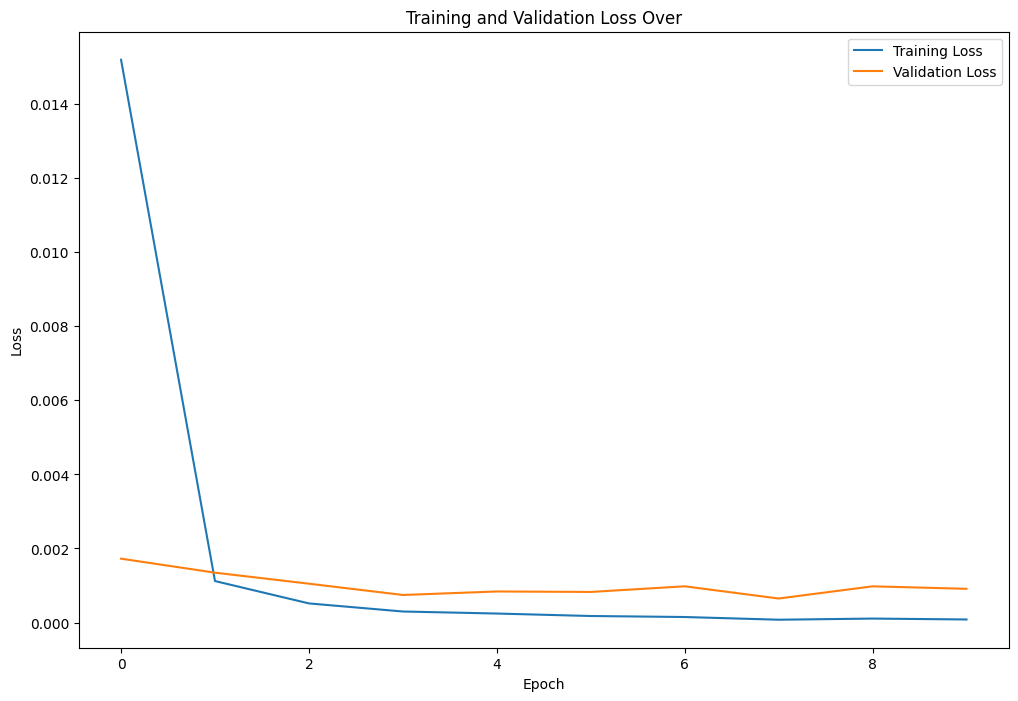

In [ ]:
# Plotting the training and validation loss
plt.figure(figsize=(12, 8))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over')
plt.legend()
plt.show()

### Saving the model

In [ ]:
torch.save(model.state_dict(), '/content/distilbert_model_weights.pth')

### Loading the saved model

In [ ]:
model.load_state_dict(torch.load('/content/distilbert_model_weights.pth'))
model.eval()  # Setting the model to evaluation mode
model.to(device)

DistilBertForTokenClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
   

### Inferencing on test data

In [ ]:
# Defining the dataset for handling tokenized data
class TestData(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings.input_ids)

In [ ]:
def tokenize_data(data, tokenizer, max_length=512):
    tokenized_inputs = tokenizer(data['full_text'].tolist(), truncation=True, padding='max_length', is_split_into_words=False, return_tensors="pt", max_length=max_length)
    return tokenized_inputs

# Tokenizing the test data
test_tokenized = tokenize_data(test_data, tokenizer)

In [ ]:
# Creating test dataset and loader
test_dataset = TestData(test_tokenized)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
# Predicting on test data
def predict_test_data(model, data_loader):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            predicted_labels = torch.argmax(logits, dim=-1)
            predictions.extend(predicted_labels.cpu().numpy())
    return predictions

# Getting predictions
test_predictions = predict_test_data(model, test_loader)

In [ ]:
def prepare_submission(tokenized_data, predictions, tokenizer, label_map, documents):
    reverse_label_map = {v: k for k, v in label_map.items()}
    submission_rows = []
    row_id = 0

    # Iterate over each example
    for idx, (input_ids, preds) in enumerate(zip(tokenized_data['input_ids'], predictions)):
        tokens = tokenizer.convert_ids_to_tokens(input_ids)
        previous_label = None
        full_token = ""
        start_token_position = 0
        document_id = documents[idx]

        for token_idx, (token, pred_label_idx) in enumerate(zip(tokens, preds)):
            if token in ['[CLS]', '[SEP]', '[PAD]']:
                continue
            if token.startswith("##"):
                full_token += token[2:]
            else:
                if previous_label != 'O' and full_token:
                    submission_rows.append({
                        'document': document_id,
                        'token': start_token_position,
                        'label': previous_label,
                        'token_str': full_token,
                        'row_id': row_id
                    })
                    row_id += 1
                full_token = token
                start_token_position = token_idx
                previous_label = reverse_label_map[pred_label_idx]

        if previous_label != 'O' and full_token:
            submission_rows.append({
                'document': document_id,
                'token': start_token_position,
                'label': previous_label,
                'token_str': full_token,
                'row_id': row_id
            })
            row_id += 1

    return pd.DataFrame(submission_rows)

In [ ]:
submission_df = prepare_submission(test_tokenized, test_predictions, tokenizer, label_map, test_data['document'])
submission_df.to_csv('submission.csv', index=False)
submission_df

,document,token,label,token_str,row_id
0,7,12,B-NAME_STUDENT,nathalie,0
1,7,15,I-NAME_STUDENT,sylla,1
2,7,474,B-NAME_STUDENT,nathalie,2
3,7,477,I-NAME_STUDENT,sylla,3
4,10,1,B-NAME_STUDENT,diego,4
5,10,2,I-NAME_STUDENT,estrada,5
6,10,444,B-NAME_STUDENT,diego,6
7,10,445,I-NAME_STUDENT,estrada,7
8,16,4,B-NAME_STUDENT,gilberto,8
9,16,6,I-NAME_STUDENT,gamboa,9


## Model Evaluation on 50% Training Subset
Evaluating per-class classification metrics (Precision, Recall, F1-Score, and F-beta Score) on 50% of the training dataset.

In [ ]:
import json
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
from transformers import DistilBertTokenizerFast, DistilBertForTokenClassification
from sklearn.metrics import precision_recall_fscore_support
import warnings

warnings.filterwarnings('ignore')

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# 1. Load the dataset
with open('/content/train.json', 'r') as file:
    data = json.load(file)
train_data = pd.json_normalize(data)

# 2. Define the label map
label_map = {
    label: i for i, label in enumerate([
        'O', 'B-NAME_STUDENT', 'I-NAME_STUDENT', 'B-URL_PERSONAL', 'I-URL_PERSONAL',
        'B-EMAIL', 'I-EMAIL', 'B-PHONE_NUM', 'I-PHONE_NUM', 'B-ID_NUM', 'I-ID_NUM',
        'B-USERNAME', 'I-USERNAME', 'B-STREET_ADDRESS', 'I-STREET_ADDRESS'
    ])
}

# 3. Initialize tokenizer and model architecture
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
model = DistilBertForTokenClassification.from_pretrained('distilbert-base-uncased', num_labels=15)

# 4. Load the saved weights into the model
model.load_state_dict(torch.load('/content/distilbert_model_weights.pth', map_location=device))
model.to(device)
model.eval() # Set to evaluation mode immediately

print("Dataset and Model Weights loaded successfully.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dataset and Model Weights loaded successfully.


In [ ]:
def tokenize_and_align_labels(data, tokenizer, label_map):
    tokenized_inputs = tokenizer(
        data['tokens'].tolist(),
        truncation=True,
        padding='max_length',
        is_split_into_words=True,
        return_tensors="pt",
        max_length=512
    )

    labels = []
    for i, label_list in enumerate(data['labels']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        previous_word_id = None
        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != previous_word_id:
                label_ids.append(label_map[label_list[word_id]])
            else:
                label_ids.append(-100)
            previous_word_id = word_id

        labels.append(torch.tensor(label_ids))

    tokenized_inputs['labels'] = pad_sequence(labels, batch_first=True, padding_value=-100)
    return tokenized_inputs

# Tokenize the loaded training data
train_tokenized = tokenize_and_align_labels(train_data, tokenizer, label_map)

# Define Dataset Class
class PIIDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings.input_ids)

In [ ]:
# 1. Create dataset and perform 50% split
torch.manual_seed(42)
full_dataset = PIIDataset(train_tokenized)

eval_size = int(0.50 * len(full_dataset))
remaining_size = len(full_dataset) - eval_size
eval_50_dataset, _ = random_split(full_dataset, [eval_size, remaining_size])

eval_50_loader = DataLoader(eval_50_dataset, batch_size=8, shuffle=False)

# 2. Evaluation Logic
def generate_classification_report(model, data_loader, label_map, device, beta=5.0):
    all_predictions = []
    all_true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            logits = outputs.logits.detach().cpu().numpy()
            label_ids = batch['labels'].detach().cpu().numpy()

            pred_flat = np.argmax(logits, axis=2).flatten()
            labels_flat = label_ids.flatten()

            # Filter out padding (-100)
            valid_mask = labels_flat != -100
            all_predictions.extend(pred_flat[valid_mask])
            all_true_labels.extend(labels_flat[valid_mask])

    id_to_label = {v: k for k, v in label_map.items()}
    class_ids = list(label_map.values())
    class_names = [id_to_label[i] for i in class_ids]

    precision, recall, f1, support = precision_recall_fscore_support(
        all_true_labels, all_predictions, labels=class_ids, average=None, zero_division=0
    )

    _, _, fbeta, _ = precision_recall_fscore_support(
        all_true_labels, all_predictions, labels=class_ids, average=None, beta=beta, zero_division=0
    )

    report_df = pd.DataFrame({
        'Label': class_names,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'F_beta-Score': fbeta,
        'Support': support
    })

    return report_df

# 3. Generate and display the report
print(f"Running evaluation on {len(eval_50_dataset)} samples...")

report_df = generate_classification_report(
    model=model,
    data_loader=eval_50_loader,
    label_map=label_map,
    device=device,
    beta=5.0
)

report_df.style.format({
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'F_beta-Score': '{:.4f}',
    'Support': '{:d}'
})

Running evaluation on 3403 samples...


,Label,Precision,Recall,F1-Score,F_beta-Score,Support
0,O,1.0000,1.0000,1.0000,1.0000,1553235
1,B-NAME_STUDENT,0.9924,0.9887,0.9906,0.9888,531
2,I-NAME_STUDENT,1.0000,0.9908,0.9954,0.9912,435
3,B-URL_PERSONAL,0.8049,1.0000,0.8919,0.9908,33
4,I-URL_PERSONAL,0.0000,0.0000,0.0000,0.0000,0
5,B-EMAIL,1.0000,0.6875,0.8148,0.6959,16
6,I-EMAIL,0.0000,0.0000,0.0000,0.0000,0
7,B-PHONE_NUM,0.0000,0.0000,0.0000,0.0000,5
8,I-PHONE_NUM,0.0000,0.0000,0.0000,0.0000,14
9,B-ID_NUM,0.9310,1.0000,0.9643,0.9972,27


In [ ]:
def get_combined_entity_metrics(report_df):
    # Filter out the 'O' (background) label
    entities_df = report_df[report_df['Label'] != 'O']

    # Macro Average (unweighted mean across entity classes)
    macro_precision = entities_df['Precision'].mean()
    macro_recall = entities_df['Recall'].mean()
    macro_f1 = entities_df['F1-Score'].mean()
    macro_fbeta = entities_df['F_beta-Score'].mean()

    # Weighted Average (weighted by support size per entity class)
    total_support = entities_df['Support'].sum()
    if total_support > 0:
        weighted_precision = (entities_df['Precision'] * entities_df['Support']).sum() / total_support
        weighted_recall = (entities_df['Recall'] * entities_df['Support']).sum() / total_support
        weighted_f1 = (entities_df['F1-Score'] * entities_df['Support']).sum() / total_support
        weighted_fbeta = (entities_df['F_beta-Score'] * entities_df['Support']).sum() / total_support
    else:
        weighted_precision = weighted_recall = weighted_f1 = weighted_fbeta = 0.0

    # Print summary table
    summary_df = pd.DataFrame({
        'Averaging Type': ['Macro Average (Unweighted)', 'Weighted Average (By Support)'],
        'Precision': [macro_precision, weighted_precision],
        'Recall': [macro_recall, weighted_recall],
        'F1-Score': [macro_f1, weighted_f1],
        'F_beta-Score (beta=5)': [macro_fbeta, weighted_fbeta]
    })

    return summary_df

# Generate and display the combined entity metrics
combined_metrics_df = get_combined_entity_metrics(report_df)

combined_metrics_df.style.format({
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'F_beta-Score (beta=5)': '{:.4f}'
})

,Averaging Type,Precision,Recall,F1-Score,F_beta-Score (beta=5)
0,Macro Average (Unweighted),0.4092,0.4048,0.4041,0.4046
1,Weighted Average (By Support),0.9696,0.9671,0.9676,0.9671
